# Maximum Likelihood: Three Visual Demos

## Demo 1: The Bank Model Climbs the Hill

**Voice-over opening:** "Let's watch a model climb to its peak — with the bank example first."

Simulate 5,000 loan applicants with income, credit utilisation, and past late payments. The population default rate is set to about 17.3%, and the random seed is 7. The notebook starts every model dial at zero, fits a logistic model by maximum likelihood, and displays the likelihood, fitted coefficients, odds ratios, and standard errors from the run.

**Caption:** `Turn the dials. Watch the likelihood climb. Stop at the peak.`

In [1]:
# Import NumPy for reproducible random daeach one has an income a credit about 17% default we ta generation and vectorized calculations.
import numpy as np

# Import pandas and display for readable data and intermediate-result tables.
import pandas as pd
from IPython.display import display

# Import Matplotlib for compatibility with the existing notebook environment.
import matplotlib.pyplot as plt

# Import SciPy's optimizer, adaptive bracketed root solver, and stable logistic function.
from scipy.optimize import brentq, minimize
from scipy.special import expit

# Set the number of simulated customers; change this to explore other sample sizes.
customer_count = 5000

# Set the expected population default rate; choose any value strictly between zero and one.
target_default_rate = 0.173

# Set the requested random seed so that rerunning the notebook reproduces the same sample.
random_generator = np.random.default_rng(7)

# Reject impossible population rates before calibrating the simulation intercept.
if not 0 < target_default_rate < 1:
    raise ValueError("target_default_rate must be strictly between 0 and 1")

# Generate positive, right-skewed incomes in arbitrary currency units.
income_raw = random_generator.lognormal(mean=10.5, sigma=0.45, size=customer_count)

# Generate credit utilisation as a fraction between zero and one.
utilisation_raw = random_generator.beta(a=2.2, b=3.0, size=customer_count)

# Generate nonnegative counts of previous late payments.
late_payments_raw = random_generator.poisson(lam=0.45, size=customer_count)

# Define a helper that expresses a feature in standard-deviation units.
def standardize_feature(values):
    # Center the feature and divide by its standard deviation for comparable coefficient scales.
    return (values - np.mean(values)) / np.std(values)

# Standardize each predictor so each coefficient describes a one-standard-deviation change.
income = standardize_feature(income_raw)
utilisation = standardize_feature(utilisation_raw)
late_payments = standardize_feature(late_payments_raw)

# Name the predictors in the same order they will appear in the model matrix.
feature_names = ["Income", "Utilisation", "Late payments"]

# Combine the standardized customer attributes into a two-dimensional predictor matrix.
predictors = np.column_stack((income, utilisation, late_payments))

# Set the simulation's underlying effects: income reduces risk, while the other features increase it.
simulation_slopes = np.array([-0.54, 0.87, 0.45])

# Calculate the linear contribution of the customer attributes before adding the intercept.
feature_log_odds = predictors @ simulation_slopes

# Define the difference between the simulated average probability and the requested population rate.
def population_rate_difference(intercept):
    # Convert the intercept-adjusted log odds into default probabilities and return their rate difference.
    return np.mean(expit(intercept + feature_log_odds)) - target_default_rate

# Begin with a small bracket around zero for the intercept calibration.
intercept_lower = -1.0
intercept_upper = 1.0

# Expand the lower endpoint until its expected default rate is no greater than the target.
while population_rate_difference(intercept_lower) > 0:
    intercept_lower *= 2

# Expand the upper endpoint until its expected default rate is no less than the target.
while population_rate_difference(intercept_upper) < 0:
    intercept_upper *= 2

# Solve for the intercept whose average generated probability matches the requested rate.
simulation_intercept = brentq(population_rate_difference, intercept_lower, intercept_upper)

# Convert each simulated customer's calibrated log odds into a default probability.
default_probabilities = expit(simulation_intercept + feature_log_odds)

# Draw each observed default outcome from its customer's simulated probability.
default_outcomes = random_generator.binomial(n=1, p=default_probabilities)

# Add a constant column so the fitted model estimates an intercept as well as three slopes.
design_matrix = np.column_stack((np.ones(customer_count), predictors))

# Show a small preview of the simulated customer data instead of flooding the notebook with all rows.
customer_preview = pd.DataFrame(
    {
        "Income": income_raw,
        "Utilisation": utilisation_raw,
        "Late payments": late_payments_raw,
        "Default probability": default_probabilities,
        "Default observed": default_outcomes,
    }
).head()

# Print the sample configuration and display the first generated customer records.
print(f"Customers simulated: {customer_count:,}")
print(f"Target population default rate: {target_default_rate:.1%}")
print(f"Observed sample default rate: {np.mean(default_outcomes):.1%}")
print("Customer data preview (first five rows):")
display(customer_preview.round(3))

Customers simulated: 5,000
Target population default rate: 17.3%
Observed sample default rate: 17.7%
Customer data preview (first five rows):


,Income,Utilisation,Late payments,Default probability,Default observed
0,36335.611,0.529,0,0.158,0
1,41540.972,0.311,0,0.058,0
2,32100.856,0.474,1,0.246,0
3,24324.362,0.209,2,0.198,1
4,29596.108,0.506,1,0.287,1


In [2]:
# Define the negative log-likelihood that the numerical optimizer will minimize.
def negative_log_likelihood(parameter_values):
    # Calculate each customer's predicted log odds from the current dial settings.
    customer_log_odds = design_matrix @ parameter_values
    # Express the binary logistic loss with logaddexp for numerical stability.
    return np.sum(np.logaddexp(0, customer_log_odds) - default_outcomes * customer_log_odds)

# Define the analytic gradient so the optimizer can efficiently update every coefficient.
def negative_log_likelihood_gradient(parameter_values):
    # Convert the current customer log odds into predicted default probabilities.
    predicted_probabilities = expit(design_matrix @ parameter_values)
    # Sum each feature's probability error to obtain the gradient for its coefficient.
    return design_matrix.T @ (predicted_probabilities - default_outcomes)

# Start every dial, including the intercept, at zero and record the initial likelihood.
initial_parameters = np.zeros(design_matrix.shape[1])
likelihood_history = [-negative_log_likelihood(initial_parameters)]

# Record the likelihood after each accepted parameter update made by the optimizer.
def record_optimizer_step(parameter_values):
    # Append this iteration's log-likelihood so the curve reflects the actual optimization path.
    likelihood_history.append(-negative_log_likelihood(parameter_values))

# Maximize the likelihood by minimizing its negative, using the analytic gradient and zero initialization.
fit_result = minimize(
    fun=negative_log_likelihood,
    x0=initial_parameters,
    jac=negative_log_likelihood_gradient,
    method="BFGS",
    callback=record_optimizer_step,
)

# Keep the optimizer's final point in the history even if a SciPy version omits its final callback.
fitted_log_likelihood = -fit_result.fun
if likelihood_history[-1] != fitted_log_likelihood:
    likelihood_history.append(fitted_log_likelihood)

# Create one row per optimizer point, including the initial all-zero guess.
optimizer_step_table = pd.DataFrame(
    {
        "Iteration": np.arange(len(likelihood_history)),
        "Log-likelihood": likelihood_history,
    }
)

# Calculate each step's likelihood gain so the shrinking improvements are visible.
optimizer_step_table["Gain from previous step"] = optimizer_step_table["Log-likelihood"].diff().fillna(0)

# Display all accepted optimizer steps as an intermediate-results table.
print("Optimizer path: likelihood and gain at every recorded step")
display(optimizer_step_table.round(3))

# Separate the fitted intercept from the predictor coefficients.
fitted_intercept = fit_result.x[0]
fitted_coefficients = fit_result.x[1:]

# Compute the fitted default probability for every customer.
fitted_probabilities = expit(design_matrix @ fit_result.x)

# Build the observed Fisher information matrix, which is the likelihood curvature at the fit.
weighted_design_matrix = design_matrix * np.sqrt(fitted_probabilities * (1 - fitted_probabilities))[:, None]
observed_information = weighted_design_matrix.T @ weighted_design_matrix

# Use the pseudoinverse to remain well-defined if predictors are redundant or nearly collinear.
coefficient_covariance = np.linalg.pinv(observed_information)

# Derive standard errors from the diagonal of the estimated coefficient covariance matrix.
all_standard_errors = np.sqrt(np.diag(coefficient_covariance))
coefficient_standard_errors = all_standard_errors[1:]

# Convert each fitted slope to its odds multiplier for a one-standard-deviation predictor increase.
fitted_odds_ratios = np.exp(fitted_coefficients)

# Report optimizer convergence and the likelihood attained at the fitted parameter values.
print(f"\nOptimizer converged: {fit_result.success} ({fit_result.message})")
print(f"Initial log-likelihood: {likelihood_history[0]:,.2f}")
print(f"Final log-likelihood:   {fitted_log_likelihood:,.2f}")

# Print each fitted slope, standard error, and odds ratio from the current simulated sample.
for name, coefficient, standard_error, odds_ratio in zip(
    feature_names,
    fitted_coefficients,
    coefficient_standard_errors,
    fitted_odds_ratios,
):
    # Display all three quantities with consistent precision while preserving coefficient signs.
    print(f"{name:<16} coefficient={coefficient:+.3f}  odds ratio={odds_ratio:.3f}  SE={standard_error:.3f}")

Optimizer path: likelihood and gain at every recorded step


,Iteration,Log-likelihood,Gain from previous step
0,0,-3465.736,0.000
1,1,-2292.648,1173.088
2,2,-2290.523,2.125
3,3,-2286.758,3.765
4,4,-2158.142,128.615
5,5,-2121.691,36.452
6,6,-2060.461,61.230
7,7,-1999.774,60.687
8,8,-1995.227,4.547
9,9,-1994.882,0.345



Optimizer converged: True (Optimization terminated successfully.)
Initial log-likelihood: -3,465.74
Final log-likelihood:   -1,994.87
Income           coefficient=-0.441  odds ratio=0.643  SE=0.049
Utilisation      coefficient=+0.847  odds ratio=2.332  SE=0.043
Late payments    coefficient=+0.443  odds ratio=1.558  SE=0.037


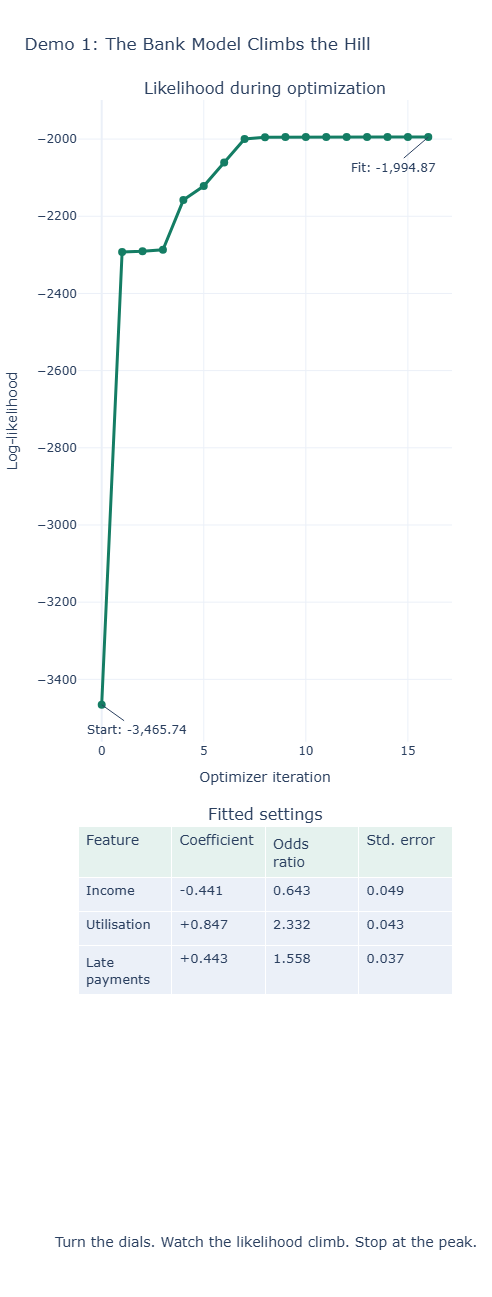

In [6]:
# Import Plotly's graph objects and subplot helper for an interactive fit summary.
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Number every recorded point, including the initial all-zero parameter guess.
iteration_numbers = np.arange(len(likelihood_history))

# Stack the likelihood chart above its fitted-statistics table for a portrait video canvas.
figure = make_subplots(
    rows=2,
    cols=1,
    row_heights=[0.66, 0.34],
    vertical_spacing=0.08,
    specs=[[{"type": "xy"}], [{"type": "table"}]],
    subplot_titles=("Likelihood during optimization", "Fitted settings"),
)

# Add every likelihood value recorded by the optimizer as an interactive line-and-marker trace.
figure.add_trace(
    go.Scatter(
        x=iteration_numbers,
        y=likelihood_history,
        mode="lines+markers",
        name="Log-likelihood",
        line={"color": "#147D64", "width": 3},
        marker={"size": 8},
        hovertemplate="Iteration %{x}<br>Log-likelihood %{y:,.2f}<extra></extra>",
    ),
    row=1,
    col=1,
)

# Add a table containing values derived from the fitted model and observed information matrix.
figure.add_trace(
    go.Table(
        header={
            "values": ["Feature", "Coefficient", "Odds ratio", "Std. error"],
            "fill_color": "#E5F2EE",
            "align": "left",
            "font": {"size": 14},
        },
        cells={
            "values": [
                feature_names,
                [f"{value:+.3f}" for value in fitted_coefficients],
                [f"{value:.3f}" for value in fitted_odds_ratios],
                [f"{value:.3f}" for value in coefficient_standard_errors],
            ],
            "align": "left",
            "height": 34,
            "font": {"size": 13},
        },
    ),
    row=2,
    col=1,
)

# Label the initial likelihood point with its value from this run.
figure.add_annotation(
    x=iteration_numbers[0],
    y=likelihood_history[0],
    text=f"Start: {likelihood_history[0]:,.2f}",
    showarrow=True,
    ax=35,
    ay=25,
    xref="x",
    yref="y",
)

# Label the fitted endpoint with the optimizer's final likelihood.
figure.add_annotation(
    x=iteration_numbers[-1],
    y=fitted_log_likelihood,
    text=f"Fit: {fitted_log_likelihood:,.2f}",
    showarrow=True,
    ax=-35,
    ay=30,
    xref="x",
    yref="y",
)

# Name the likelihood chart axes.
figure.update_xaxes(title_text="Optimizer iteration", row=1, col=1)
figure.update_yaxes(title_text="Log-likelihood", row=1, col=1)

# Place the requested caption below the stacked chart and table.
figure.add_annotation(
    x=0.5,
    y=-0.09,
    xref="paper",
    yref="paper",
    text="Turn the dials. Watch the likelihood climb. Stop at the peak.",
    showarrow=False,
    font={"size": 14},
)

# Use an exact 9:16 portrait canvas and enable interactive hover details.
figure.update_layout(
    title="Demo 1: The Bank Model Climbs the Hill",
    template="plotly_white",
    width=720,
    height=1280,
    autosize=False,
    margin={"l": 70, "r": 40, "t": 100, "b": 140},
    hovermode="closest",
)

# Render the interactive portrait graph and fitted-statistics table.
figure.show()

### Insights

The likelihood rises quickly from the all-zero guess, then levels as the optimizer converges. The negative income coefficient indicates lower default odds as income rises; positive utilisation and late-payment coefficients indicate higher odds. Odds ratios describe the change in odds for a one-standard-deviation increase in each simulated feature. Standard errors summarize uncertainty around the fitted coefficients.

## Demo 2: The Coin That Learns

We observed 7 heads in 10 flips. For each possible heads probability, the likelihood is the probability of observing exactly 7 heads in 10 independent flips. The curve's peak gives the maximum-likelihood estimate, which is the observed fraction of heads.

**Voice-over:** "Seven heads in ten flips. How believable is each possible coin?"

**Caption:** `Likelihood: how believable is each setting, given what we saw?`

Observed data: 7 heads in 10 flips


,Outcome,Count,Fraction of flips
0,Heads,7,0.7
1,Tails,3,0.3


Candidate likelihoods (larger means this setting better explains the observed count):


,Candidate p,Likelihood,Relative to peak
0,0.3,0.009,0.034
1,0.5,0.117,0.439
2,0.7,0.267,1.000
3,0.9,0.057,0.215


Maximum-likelihood estimate: p_hat = 0.7


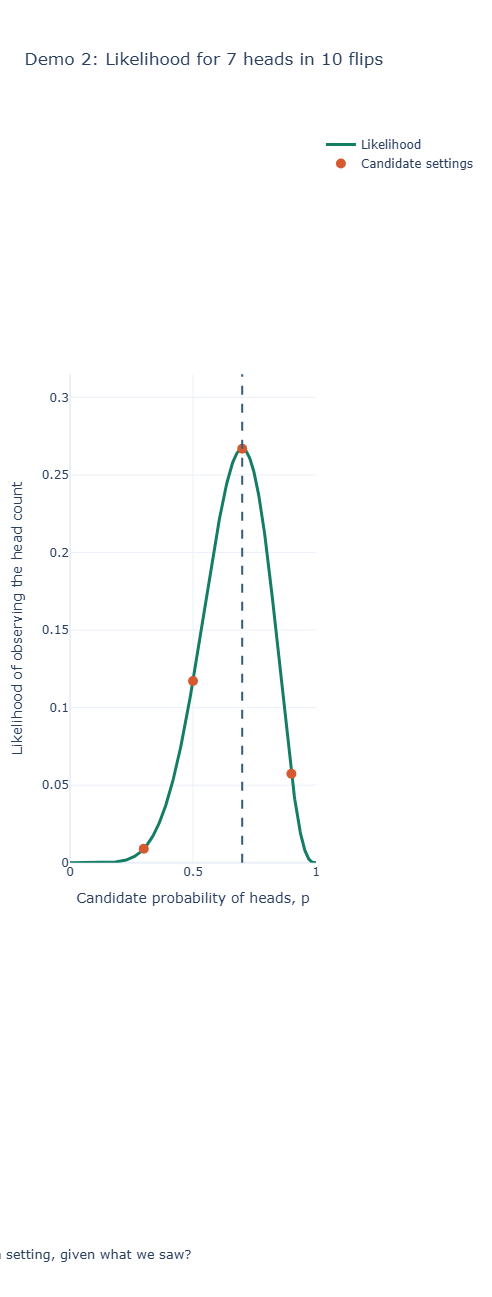

In [7]:
# Import Plotly for interactive charts and stable special functions for binomial likelihoods.
import plotly.graph_objects as go
from scipy.special import gammaln, xlogy

# Set the observed number of heads and total flips for this coin example.
coin_heads = 7
coin_flips = 10

# Calculate the number of observed tails from the other counts.
coin_tails = coin_flips - coin_heads

# Define a numerically stable likelihood for observing a head count at a candidate probability.
def coin_count_likelihood(head_count, flip_count, heads_probability):
    # Derive the number of tails represented by the observed head count.
    tail_count = flip_count - head_count
    # Calculate the log binomial coefficient without converting a large integer directly.
    log_combinations = gammaln(flip_count + 1) - gammaln(head_count + 1) - gammaln(tail_count + 1)
    # Calculate the log likelihood stably, including candidate probabilities at zero or one.
    log_likelihood = log_combinations + xlogy(head_count, heads_probability) + xlogy(
        tail_count, 1 - heads_probability
    )
    # Convert the log likelihood to the probability of observing this head count.
    return np.exp(log_likelihood)

# Create candidate probability settings covering the complete range from zero to one.
possible_probabilities = np.linspace(0, 1, 501)

# Evaluate the likelihood of the observed data at every candidate probability.
coin_likelihoods = coin_count_likelihood(coin_heads, coin_flips, possible_probabilities)

# Calculate the maximum-likelihood estimate as the fraction of observed flips that were heads.
coin_probability_estimate = coin_heads / coin_flips

# Store the candidate settings used in the requested narrated comparison.
marked_probabilities = np.array([0.3, 0.5, 0.7, 0.9])

# Calculate the likelihood values at those candidate settings directly from the data.
marked_likelihoods = coin_count_likelihood(coin_heads, coin_flips, marked_probabilities)

# Calculate the peak likelihood so the candidate likelihoods can be compared on a relative scale.
coin_peak_likelihood = coin_count_likelihood(coin_heads, coin_flips, coin_probability_estimate)
marked_relative_likelihoods = marked_likelihoods / coin_peak_likelihood

# Create a compact table that makes the observed coin data explicit.
coin_data_table = pd.DataFrame(
    {
        "Outcome": ["Heads", "Tails"],
        "Count": [coin_heads, coin_tails],
        "Fraction of flips": [coin_heads / coin_flips, coin_tails / coin_flips],
    }
)

# Create a table of every narrated candidate and its calculated likelihood.
coin_candidate_table = pd.DataFrame(
    {
        "Candidate p": marked_probabilities,
        "Likelihood": marked_likelihoods,
        "Relative to peak": marked_relative_likelihoods,
    }
)

# Print the observed data table before showing the candidate settings.
print(f"Observed data: {coin_heads} heads in {coin_flips} flips")
display(coin_data_table.round(3))

# Print the intermediate likelihood calculations for the narrated candidate probabilities.
print("Candidate likelihoods (larger means this setting better explains the observed count):")
display(coin_candidate_table.round(3))
print(f"Maximum-likelihood estimate: p_hat = {coin_probability_estimate:.1f}")

# Create an interactive figure for the likelihood curve and requested candidate settings.
figure = go.Figure()

# Draw the likelihood across the full range of possible heads probabilities.
figure.add_trace(
    go.Scatter(
        x=possible_probabilities,
        y=coin_likelihoods,
        mode="lines",
        name="Likelihood",
        line={"color": "#147D64", "width": 3},
        hovertemplate="p = %{x:.3f}<br>Likelihood = %{y:.3f}<extra></extra>",
    )
)

# Mark the four candidate probabilities from the narrated comparison.
figure.add_trace(
    go.Scatter(
        x=marked_probabilities,
        y=marked_likelihoods,
        mode="markers",
        name="Candidate settings",
        marker={"color": "#D65A31", "size": 10},
        customdata=marked_probabilities,
        hovertemplate="p = %{customdata:.1f}<br>Likelihood = %{y:.3f}<extra></extra>",
    )
)

# Draw a vertical reference at the maximum-likelihood estimate.
figure.add_vline(
    x=coin_probability_estimate,
    line_dash="dash",
    line_color="#355C7D",
    annotation_text=f"p_hat = {coin_probability_estimate:.1f}",
    annotation_position="top left",
)

# Configure a 9:16 interactive layout with a dynamic vertical scale and caption.
figure.update_layout(
    title=f"Demo 2: Likelihood for {coin_heads} heads in {coin_flips} flips",
    template="plotly_white",
    width=720,
    height=1280,
    autosize=False,
    hovermode="closest",
    xaxis_title="Candidate probability of heads, p",
    yaxis_title="Likelihood of observing the head count",
    yaxis_range=[0, float(np.max(coin_likelihoods)) * 1.18],
    margin={"l": 70, "r": 35, "t": 130, "b": 190},
    annotations=[
        {
            "x": 0.5,
            "y": -0.14,
            "xref": "paper",
            "yref": "paper",
            "text": "Likelihood: how believable is each setting, given what we saw?",
            "showarrow": False,
            "font": {"size": 13},
        }
    ],
)

# Keep the data curve near-square within the taller 9:16 canvas.
figure.update_yaxes(domain=[0.25, 0.75])

# Render the interactive portrait likelihood curve.
figure.show()

### Insights

The curve peaks at `p = 0.7`, matching the observed fraction of heads, `7/10`. Among the marked settings, `p = 0.7` makes the observed count most likely. Hover over the curve to compare likelihoods between the printed points.

## Demo 3: More Data = Sharper Peak

Compare 7 heads in 10 flips with 70 heads in 100 flips. Both samples have the same observed fraction of heads. Each curve is divided by its own peak so the shape and relative plausibility are easy to compare.

**Voice-over:** "Same proportion. Ten flips versus a hundred. Ten flips gives a fat, lazy hill. A hundred gives a tight spike."

The standard error is calculated as `sqrt(p_hat * (1 - p_hat) / n)`. The fair-coin comparison is the likelihood at `p = 0.5` divided by the likelihood at the fitted peak.

**Caption:** `Sharper peak = tighter uncertainty.`

Observed data comparison: 7 heads in 10 flips and 70 heads in 100 flips
Each curve is divided by its own peak; the table shows the intermediate calculations.


,Flips,Heads,Estimated p,Peak likelihood,Fair coin likelihood,Fair / peak,Standard error
0,10,7,0.7,0.266828,0.117188,0.439188,0.145
1,100,70,0.7,0.086784,0.000023,0.000267,0.046


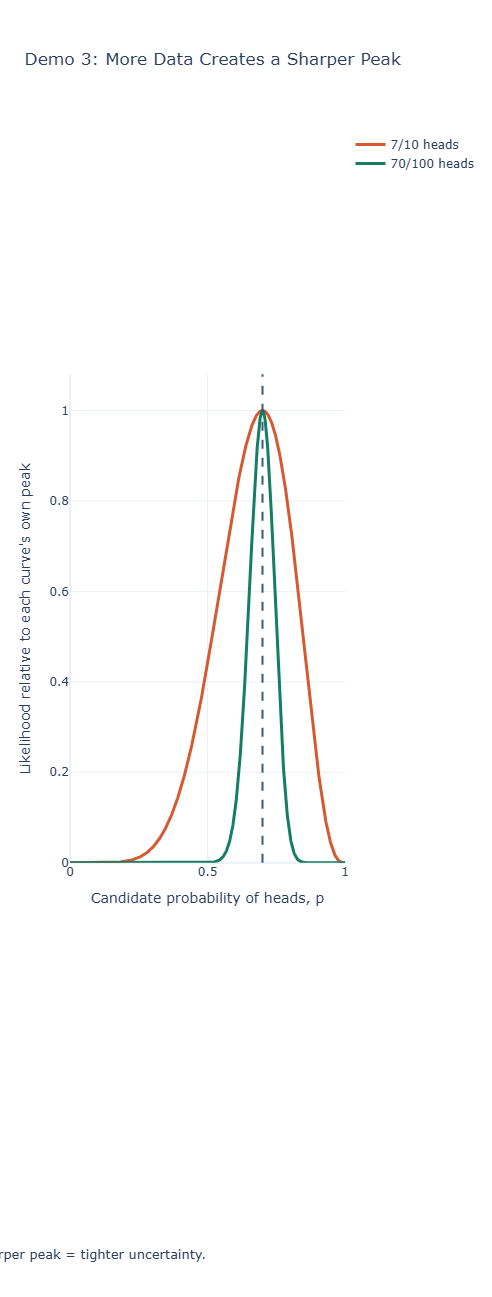

In [9]:
# Import Plotly for an interactive portrait comparison of the two likelihood curves.
import plotly.graph_objects as go

# Set the two observed sample sizes and head counts that have the same observed proportion.
coin_samples = [(10, 7), (100, 70)]

# Define the fair-coin probability used to compare each sample with its fitted peak.
fair_coin_probability = 0.5

# Create a fine grid of candidate probabilities for smooth interactive curves.
probability_grid = np.linspace(0, 1, 1001)

# Choose distinct colors so viewers can identify each sample size.
curve_colors = ["#D65A31", "#147D64"]

# Store each sample's intermediate and final calculations for a readable results table.
coin_summaries = []

# Create the interactive figure before adding the two normalized likelihood curves.
figure = go.Figure()

# Calculate, print, and plot each sample's peak and relative likelihood.
for (flip_count, head_count), curve_color in zip(coin_samples, curve_colors):
    # Calculate the sample's maximum-likelihood estimate from its observed head fraction.
    estimated_probability = head_count / flip_count

    # Calculate the likelihood across the full probability grid.
    likelihood_curve = coin_count_likelihood(head_count, flip_count, probability_grid)

    # Calculate the likelihood at the fitted peak for normalization.
    peak_likelihood = coin_count_likelihood(head_count, flip_count, estimated_probability)

    # Divide by the peak so both curves have a maximum value of one.
    relative_likelihood_curve = likelihood_curve / peak_likelihood

    # Calculate the standard error of the estimated probability for this sample size.
    estimate_standard_error = np.sqrt(
        estimated_probability * (1 - estimated_probability) / flip_count
    )

    # Calculate the absolute likelihood of the fair-coin setting.
    fair_coin_likelihood = coin_count_likelihood(head_count, flip_count, fair_coin_probability)

    # Compare the fair-coin likelihood directly with the fitted peak likelihood.
    fair_coin_relative_likelihood = fair_coin_likelihood / peak_likelihood

    # Save the observed data and every intermediate statistic for the output table.
    coin_summaries.append(
        {
            "Flips": flip_count,
            "Heads": head_count,
            "Estimated p": estimated_probability,
            "Peak likelihood": peak_likelihood,
            "Fair coin likelihood": fair_coin_likelihood,
            "Fair / peak": fair_coin_relative_likelihood,
            "Standard error": estimate_standard_error,
        }
    )

    # Add the normalized likelihood as a hoverable Plotly line.
    figure.add_trace(
        go.Scatter(
            x=probability_grid,
            y=relative_likelihood_curve,
            mode="lines",
            name=f"{head_count}/{flip_count} heads",
            line={"color": curve_color, "width": 3},
            hovertemplate="p = %{x:.3f}<br>Relative likelihood = %{y:.5f}<extra>%{fullData.name}</extra>",
        )
    )

# Calculate the shared fitted probability from the first sample's observed fraction.
shared_estimate = coin_samples[0][1] / coin_samples[0][0]

# Mark the common peak location so the matching estimates are easy to compare.
figure.add_vline(
    x=shared_estimate,
    line_dash="dash",
    line_color="#355C7D",
    annotation_text=f"p_hat = {shared_estimate:.1f}",
    annotation_position="top left",
)

# Label the graph and set the exact 9:16 Instagram Reel canvas dimensions.
figure.update_layout(
    title="Demo 3: More Data Creates a Sharper Peak",
    template="plotly_white",
    width=720,
    height=1280,
    autosize=False,
    hovermode="x unified",
    xaxis_title="Candidate probability of heads, p",
    yaxis_title="Likelihood relative to each curve's own peak",
    yaxis_range=[0, 1.08],
    margin={"l": 70, "r": 35, "t": 130, "b": 190},
    annotations=[
        {
            "x": 0.5,
            "y": -0.14,
            "xref": "paper",
            "yref": "paper",
            "text": "Sharper peak = tighter uncertainty.",
            "showarrow": False,
            "font": {"size": 13},
        }
    ],
)

# Keep the comparison curves near-square inside the taller portrait canvas.
figure.update_yaxes(domain=[0.25, 0.75])

# Print the observations and explain the normalized likelihood scale.
print("Observed data comparison: 7 heads in 10 flips and 70 heads in 100 flips")
print("Each curve is divided by its own peak; the table shows the intermediate calculations.")

# Convert the saved calculations into a readable table.
coin_comparison_table = pd.DataFrame(coin_summaries)

# Round displayed values without requiring optional notebook table-formatting packages.
coin_comparison_table = coin_comparison_table.round(
    {
        "Estimated p": 3,
        "Peak likelihood": 6,
        "Fair coin likelihood": 6,
        "Fair / peak": 6,
        "Standard error": 3,
    }
)

# Display the estimate, peak likelihood, fair-coin comparison, and uncertainty for each sample.
display(coin_comparison_table)

# Render the interactive portrait small-sample versus large-sample comparison.
figure.show()

### Insights

Both samples peak at `p = 0.7`, but the 100-flip curve is much narrower. Its standard error is about `0.046`, compared with `0.145` for 10 flips. A fair coin has about `0.44x` the peak likelihood with 10 flips, but only about `1 in 3,745` of the peak likelihood with 100 flips. More observations sharpen the estimate without changing the observed proportion.